**Author**: Felipe Matheus <br>
**Start Date**: 14/04/2026 <br>
**End Date**: --/--/2026 <br>
**Related Links**:
- `eda_clusterization.ipynb` — exploratory analysis
- `data/raw/elements_composition/compositions.py` — raw sample dicts

**Objective:**

Apply unsupervised clustering (K-Means, K-Means++, Hierarchical, GMM) with K ∈ {2, 3, 4} across three datasets derived from the SPECTRO Cu-10-F measurements:
- **Dataset A** — original 9 samples (point estimates)
- **Dataset B** — 100 Monte Carlo draws per sample, `below_limit_zero=True` (900 rows)
- **Dataset C** — 100 Monte Carlo draws per sample, `below_limit_zero=False` (900 rows)

---
## 1 · Setup

In [25]:
import os
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.DataLoader import DataLoader as load
from src.feature_engineering.FeatureEngineering import FeatureEngineering as feng
from src.modeling.modeling import Modeling as modl
from src.visualization.Plots import Plots as plot

warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
SEED = 42
KS   = (2, 3, 4)
N_MC = 100          # Monte Carlo draws per sample

ALGOS = ["KMeans", "KMeans++", "Hierarchical", "GMM"]

# ── Feature-selection knobs ────────────────────────────────────────────
# TIERS:          None            → all elements (current behaviour)
#                 ["tier1"]       → P, Fe, Si, As, Sb  (severe conductivity)
#                 ["tier1","tier2"]→ + Sn, Mn, Ni, Cr, Al  (moderate)
#                 ["tier1","tier2","tier3"] → + Ag, Zn, Pb, Mg, B, Te
DROP_DISCARDED = False   # True → remove near-zero-variance elements
TIERS          = None    # see above

---
## 2 · Load compositions

In [27]:
compositions_path = os.path.abspath(os.path.join('../../data/raw/elements_composition'))
if compositions_path not in sys.path:
    sys.path.append(compositions_path)

from compositions import (
    sac_1A_sac1,
    sac_1A_sac2,
    sac_1B_sac1,
    sac_1B_sac2,
    sac_1B_sac3,
    sac_1B_sac4,
    sac_1B_sac6,
    sac_2N_sac1,
    sac_2N_sac2,
    ALL_SAMPLES,
)

print(f"{len(ALL_SAMPLES)} samples loaded: {list(ALL_SAMPLES.keys())}")

9 samples loaded: ['1A sac1', '1A sac2', '1B sac1', '1B sac2', '1B sac3', '1B sac4', '1B sac6', '2N sac1', '2N sac2']


---
## 3 · Build datasets

### Dataset A — Original point estimates (9 rows)
One row per sample using the raw mean concentrations.  
`below_limit_zero=False` keeps detection-limit values as their nominal measurement.

In [28]:
df_A = feng.build_dataset(
    ALL_SAMPLES,
    below_limit_zero=False,
    mc_augment=False,
    tiers=TIERS,
    drop_discarded=DROP_DISCARDED,
)
print(f"Dataset A shape: {df_A.shape}")
df_A

Dataset A shape: (9, 26)


,Zn,Pb,Sn,P,Mn,Fe,Ni,Si,Mg,Cr,...,Al,S,Be,Zr,Au,B,Ti,Pt,Cu,Te
sample,,,,,,,,,,,,,,,,,,,,,
1A sac1,0.0010,0.0003,0.0002,0.00020,0.0004,0.00110,0.00020,0.00100,0.00026,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00047,0.00020,0.002,99.98,0.0017
1A sac2,0.0010,0.0003,0.0002,0.00020,0.0004,0.00110,0.00020,0.00100,0.00026,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00047,0.00020,0.002,99.98,0.0019
1B sac1,0.0014,0.0003,0.0137,0.00020,0.0004,0.00120,0.00020,0.00110,0.00021,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00051,0.00020,0.002,99.97,0.0020
1B sac2,0.0011,0.0003,0.0037,0.00020,0.0004,0.00088,0.00020,0.00088,0.00017,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00043,0.00020,0.002,99.98,0.0020
1B sac3,0.0014,0.0100,0.0033,0.00020,0.0004,0.00079,0.00020,0.00095,0.00021,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00040,0.00020,0.002,99.97,0.0021
1B sac4,0.0101,0.0053,0.0199,0.00026,0.0004,0.00150,0.00020,0.00170,0.00031,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00048,0.00024,0.002,99.95,0.0029
1B sac6,0.0010,0.0003,0.0195,0.00020,0.0004,0.00090,0.00020,0.00084,0.00017,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00043,0.00020,0.002,99.96,0.0022
2N sac1,0.0061,0.0332,0.0060,0.00020,0.0004,0.00130,0.00034,0.00080,0.00017,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00046,0.00020,0.002,99.94,0.0021
2N sac2,0.0010,0.3020,0.0055,0.00020,0.0004,0.00120,0.00020,0.00085,0.00017,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00045,0.00020,0.002,99.67,0.0020


### Dataset B — Monte Carlo · `below_limit_zero=True` (900 rows)
100 draws per sample. Below-detection elements are fixed at **0.0** — no variance injected for uncertain values.

In [29]:
df_B = feng.build_dataset(
    ALL_SAMPLES,
    below_limit_zero=True,
    mc_augment=True,
    n_mc=N_MC,
    seed=SEED,
    tiers=TIERS,
    drop_discarded=DROP_DISCARDED,
)
print(f"Dataset B shape: {df_B.shape}")
df_B.head()

Dataset B shape: (900, 26)


,Zn,Pb,Sn,P,Mn,Fe,Ni,Si,Mg,Cr,...,Al,S,Be,Zr,Au,B,Ti,Pt,Cu,Te
0,0.0,0.0,0.0,0.0,0.0,0.001167,0.0,0.000966,0.000263,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000516,0.0,0.0,99.98,0.001978
1,0.0,0.0,0.0,0.0,0.0,0.000871,0.0,0.001117,0.000274,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000418,0.0,0.0,99.98,0.001639
2,0.0,0.0,0.0,0.0,0.0,0.001265,0.0,0.000968,0.000261,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000585,0.0,0.0,99.98,0.001442
3,0.0,0.0,0.0,0.0,0.0,0.001307,0.0,0.001066,0.000266,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000414,0.0,0.0,99.98,0.001686
4,0.0,0.0,0.0,0.0,0.0,0.000671,0.0,0.000916,0.000239,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000413,0.0,0.0,99.98,0.001962


### Dataset C — Monte Carlo · `below_limit_zero=False` (900 rows)
100 draws per sample. Below-detection elements are **also sampled** from N(val, sd) using the detection-limit value as mean — propagates uncertainty even for near-limit elements.

In [30]:
df_C = feng.build_dataset(
    ALL_SAMPLES,
    below_limit_zero=False,
    mc_augment=True,
    n_mc=N_MC,
    seed=SEED,
    tiers=TIERS,
    drop_discarded=DROP_DISCARDED,
)
print(f"Dataset C shape: {df_C.shape}")
df_C.head()

Dataset C shape: (900, 26)


,Zn,Pb,Sn,P,Mn,Fe,Ni,Si,Mg,Cr,...,Al,S,Be,Zr,Au,B,Ti,Pt,Cu,Te
0,0.001,0.0003,0.0002,0.0002,0.0004,0.001167,0.0002,0.000966,0.000263,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000516,0.0002,0.002,99.98,0.001978
1,0.001,0.0003,0.0002,0.0002,0.0004,0.000871,0.0002,0.001117,0.000274,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000418,0.0002,0.002,99.98,0.001639
2,0.001,0.0003,0.0002,0.0002,0.0004,0.001265,0.0002,0.000968,0.000261,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000585,0.0002,0.002,99.98,0.001442
3,0.001,0.0003,0.0002,0.0002,0.0004,0.001307,0.0002,0.001066,0.000266,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000414,0.0002,0.002,99.98,0.001686
4,0.001,0.0003,0.0002,0.0002,0.0004,0.000671,0.0002,0.000916,0.000239,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000413,0.0002,0.002,99.98,0.001962


---
## 4 · Clustering — Dataset A (Original, 9 samples)

In [31]:
summary_A, results_A = modl.run_all(df_A, ks=KS, seed=SEED)
summary_A

Silhouette  Inertia     BIC     AIC
Algorithm    K                                     
GMM          2      0.1671      NaN -221.17 -274.62
             3      0.1506      NaN -316.25 -396.52
             4      0.1699      NaN -135.70 -242.79
Hierarchical 2      0.4482      NaN     NaN     NaN
             3      0.2457      NaN     NaN     NaN
             4      0.2199      NaN     NaN     NaN
KMeans       2      0.4482  73.5433     NaN     NaN
             3      0.1504  53.1714     NaN     NaN
             4      0.2199  31.5732     NaN     NaN
KMeans++     2      0.4482  73.5433     NaN     NaN
             3      0.2457  50.8620     NaN     NaN
             4      0.2199  31.5732     NaN     NaN

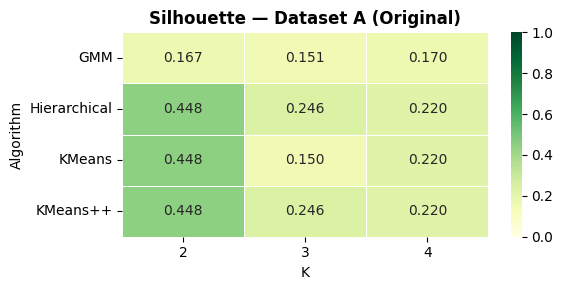

In [32]:
plot.plot_silhouette_heatmap(summary_A, "Silhouette — Dataset A (Original)")

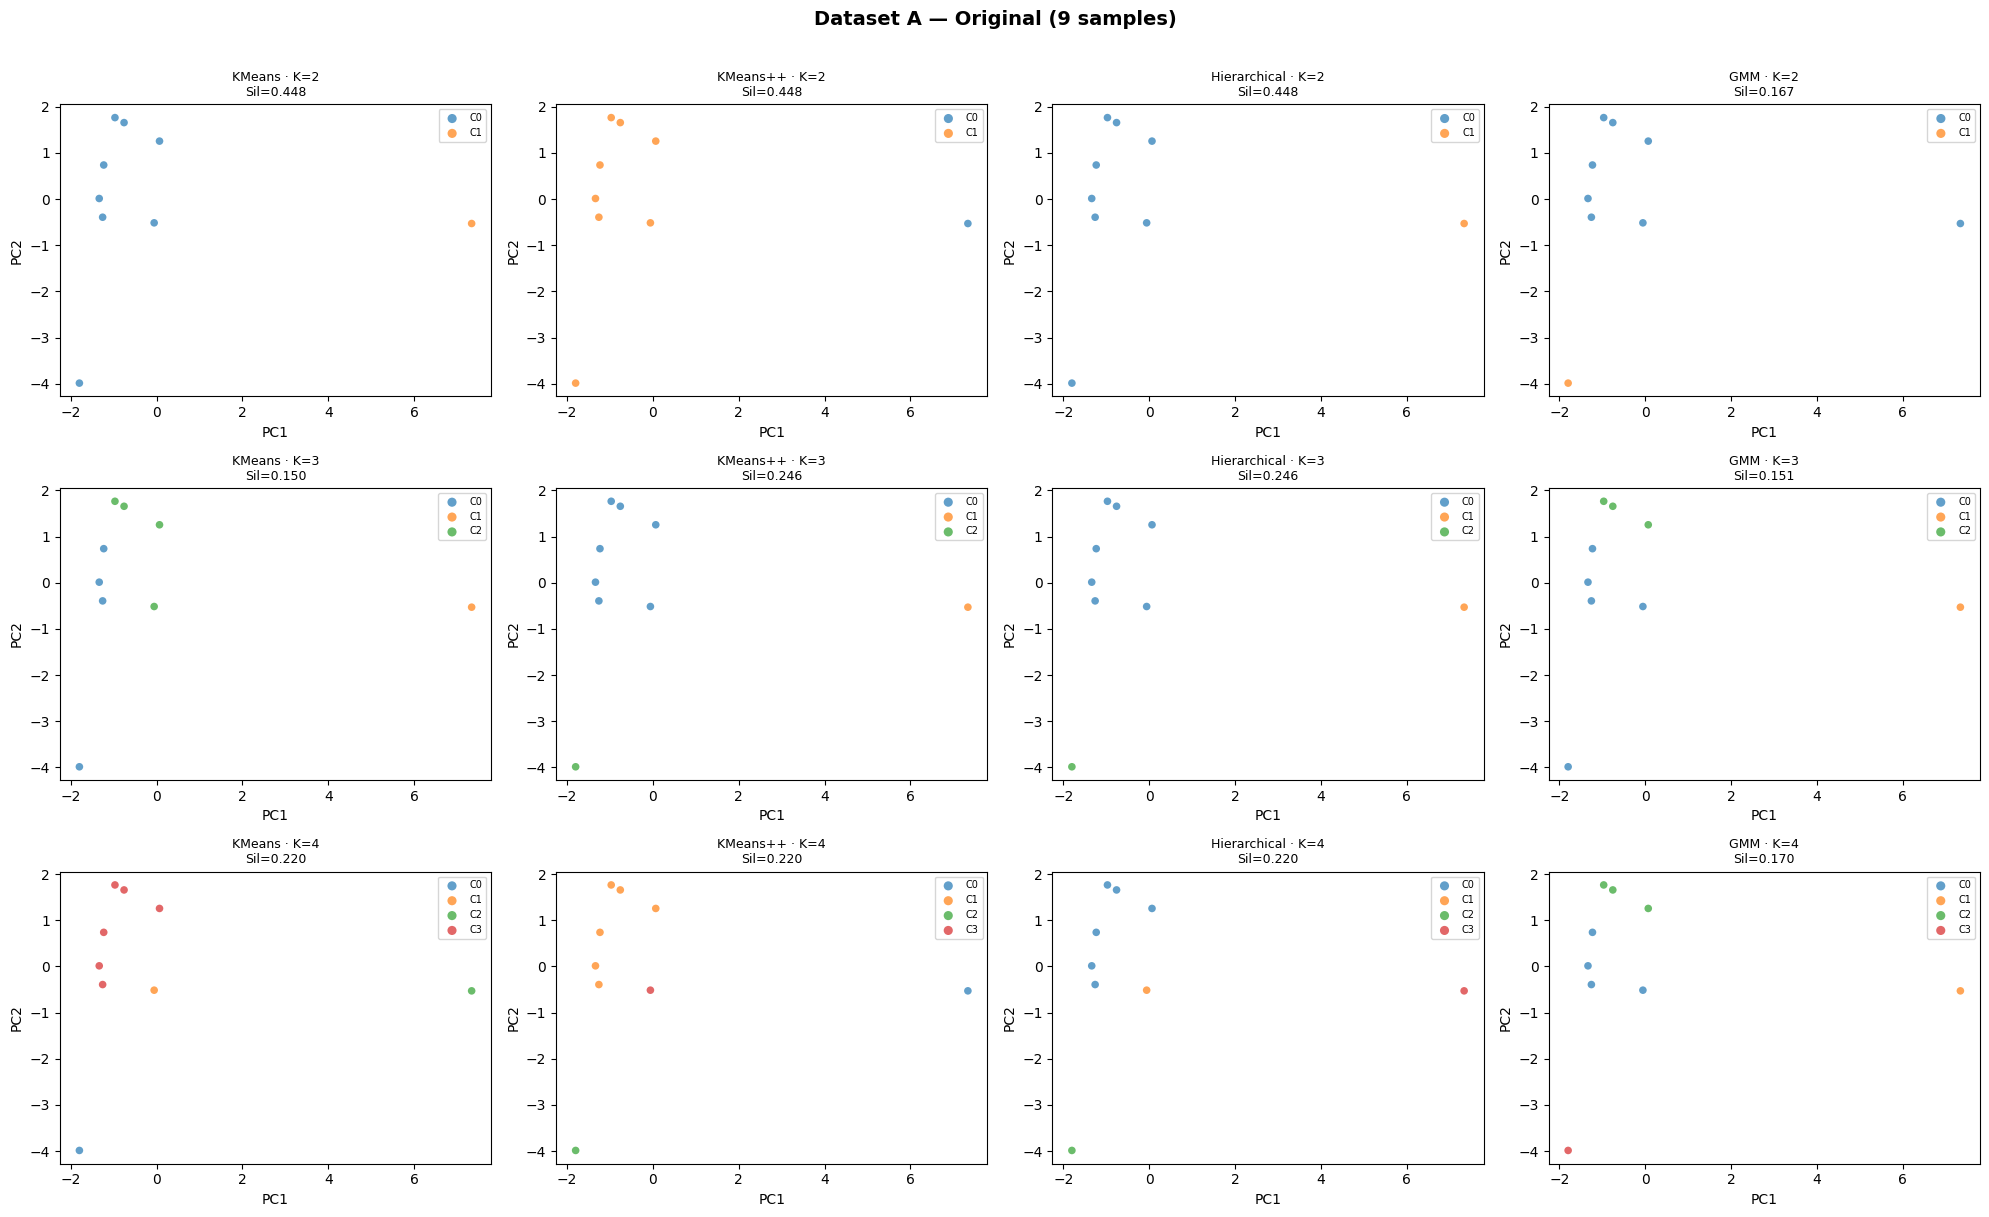

In [33]:
plot.plot_clusters_pca(
    df_feat=df_A,
    algos=ALGOS,
    results=results_A,
    title="Dataset A — Original (9 samples)",
    ks=KS,
)

---
## 5 · Clustering — Dataset B (MC · `below_limit_zero=True`, 900 rows)

In [34]:
summary_B, results_B = modl.run_all(df_B, ks=KS, seed=SEED)
summary_B

Silhouette    Inertia       BIC       AIC
Algorithm    K                                           
GMM          2      0.2804        NaN   8976.50   7675.05
             3      0.3909        NaN -16473.54 -18428.11
             4      0.4506        NaN -23831.89 -26439.59
Hierarchical 2      0.4797        NaN       NaN       NaN
             3      0.3843        NaN       NaN       NaN
             4      0.4506        NaN       NaN       NaN
KMeans       2      0.4797  9034.9946       NaN       NaN
             3      0.3843  6983.8452       NaN       NaN
             4      0.4506  5044.0357       NaN       NaN
KMeans++     2      0.4797  9034.9946       NaN       NaN
             3      0.3920  7006.1281       NaN       NaN
             4      0.4506  5044.0357       NaN       NaN

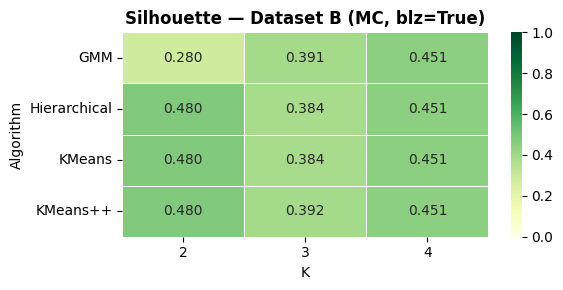

In [35]:
plot.plot_silhouette_heatmap(summary_B, "Silhouette — Dataset B (MC, blz=True)")

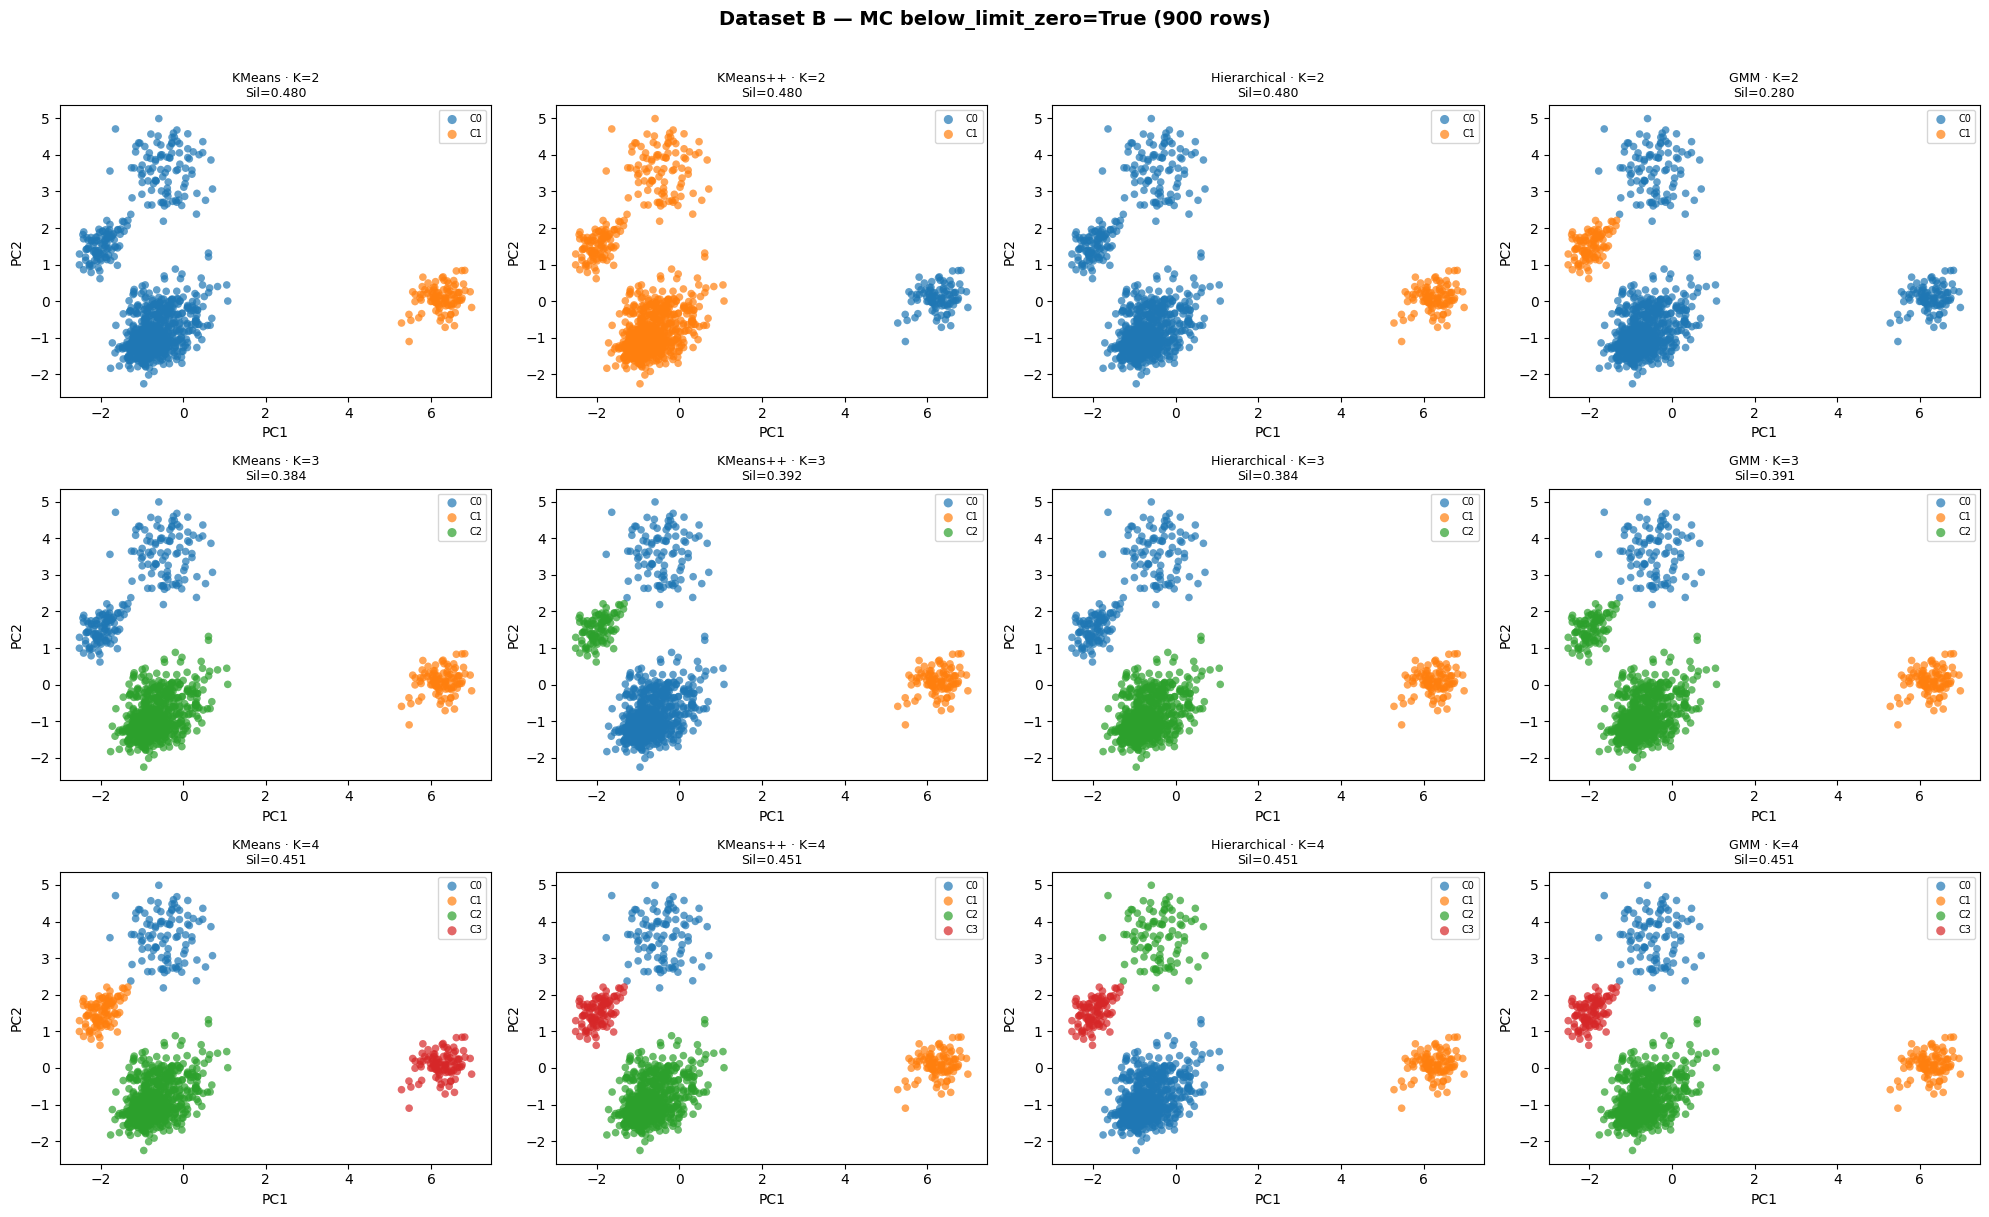

In [36]:
plot.plot_clusters_pca(
    df_feat=df_B,
    algos=ALGOS,
    results=results_B,
    title="Dataset B — MC below_limit_zero=True (900 rows)",
    ks=KS,
)

---
## 6 · Clustering — Dataset C (MC · `below_limit_zero=False`, 900 rows)

In [37]:
summary_C, results_C = modl.run_all(df_C, ks=KS, seed=SEED)
summary_C

Silhouette    Inertia        BIC        AIC
Algorithm    K                                             
GMM          2      0.2803        NaN -101293.24 -104919.05
             3      0.3087        NaN -129642.95 -135084.07
             4      0.3896        NaN -134662.02 -141918.44
Hierarchical 2      0.4735        NaN        NaN        NaN
             3      0.3791        NaN        NaN        NaN
             4      0.3896        NaN        NaN        NaN
KMeans       2      0.4735  9239.3832        NaN        NaN
             3      0.3791  7217.8486        NaN        NaN
             4      0.3978  5862.0209        NaN        NaN
KMeans++     2      0.4735  9239.3832        NaN        NaN
             3      0.3791  7217.8486        NaN        NaN
             4      0.3978  5862.0209        NaN        NaN

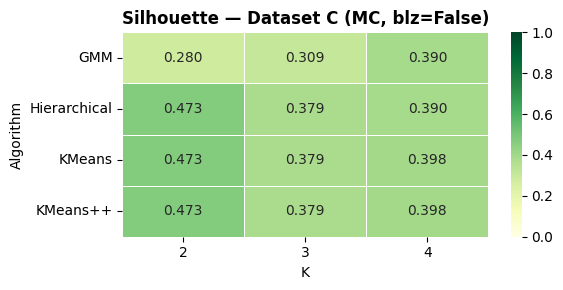

In [38]:
plot.plot_silhouette_heatmap(summary_C, "Silhouette — Dataset C (MC, blz=False)")

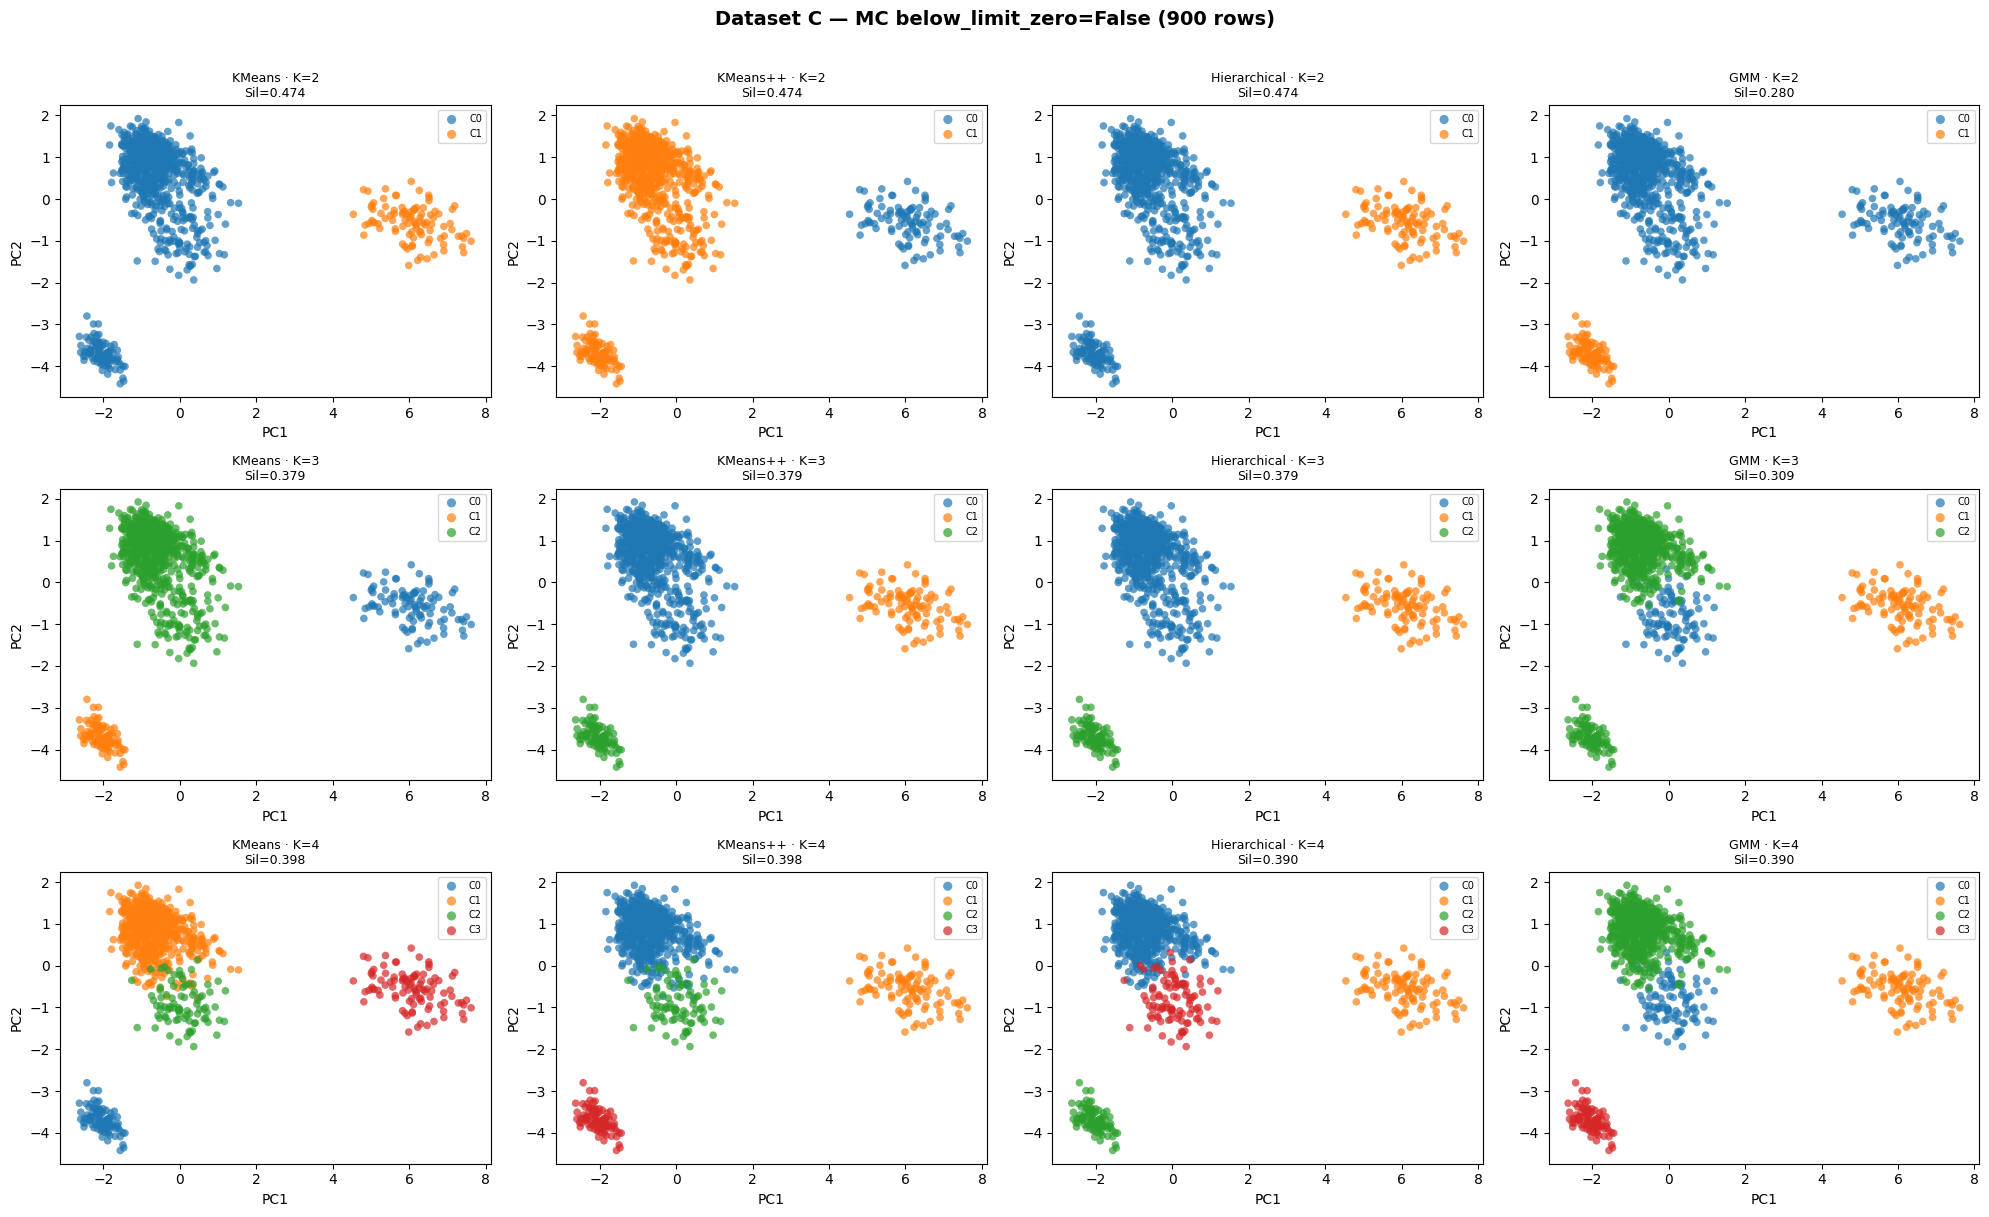

In [39]:
plot.plot_clusters_pca(
    df_feat=df_C,
    algos=ALGOS,
    results=results_C,
    title="Dataset C — MC below_limit_zero=False (900 rows)",
    ks=KS,
)

---
## 7 · Cross-dataset comparison

In [40]:
def add_dataset_label(summary: pd.DataFrame, label: str) -> pd.DataFrame:
    df = summary[["Silhouette"]].copy()
    df.columns = pd.MultiIndex.from_tuples([(label, "Silhouette")])
    return df

comparison = pd.concat([
    add_dataset_label(summary_A, "A · Original"),
    add_dataset_label(summary_B, "B · MC blz=True"),
    add_dataset_label(summary_C, "C · MC blz=False"),
], axis=1)

comparison

A · Original B · MC blz=True C · MC blz=False
                 Silhouette      Silhouette       Silhouette
Algorithm    K                                              
GMM          2       0.1671          0.2804           0.2803
             3       0.1506          0.3909           0.3087
             4       0.1699          0.4506           0.3896
Hierarchical 2       0.4482          0.4797           0.4735
             3       0.2457          0.3843           0.3791
             4       0.2199          0.4506           0.3896
KMeans       2       0.4482          0.4797           0.4735
             3       0.1504          0.3843           0.3791
             4       0.2199          0.4506           0.3978
KMeans++     2       0.4482          0.4797           0.4735
             3       0.2457          0.3920           0.3791
             4       0.2199          0.4506           0.3978

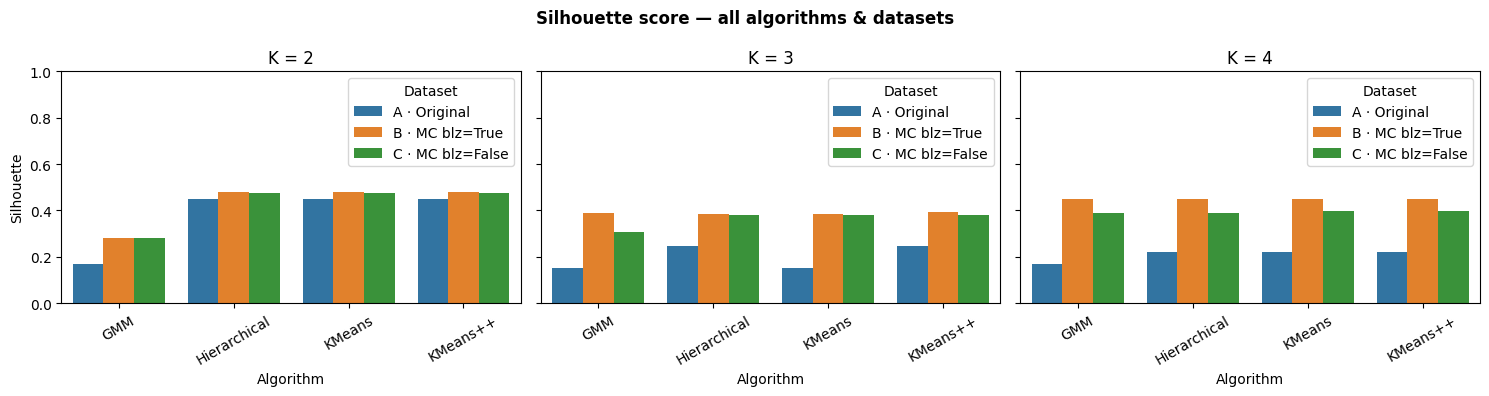

In [41]:
plot.plot_silhouette_comparison(
    summaries=[
        (summary_A, "A · Original"),
        (summary_B, "B · MC blz=True"),
        (summary_C, "C · MC blz=False"),
    ],
    ks=KS,
)

---
## 8 · Classify new samples

Generate synthetic samples, assign them to the clusters fitted on **Dataset C**, and visualise where they land in PCA space.

### 8.1 · Generate dummy samples

Each new sample is a convex combination of two randomly chosen originals:
`new = α · sampleA + (1 − α) · sampleB`, with α ∈ [0.2, 0.8].

In [42]:
import numpy as np

N_NEW   = 80
rng     = np.random.default_rng(99)

flat_samples  = {name: load.to_flat(s, below_limit_zero=False)
                 for name, s in ALL_SAMPLES.items()}
sample_names  = list(flat_samples.keys())

new_rows, new_idx = [], []
for i in range(N_NEW):
    s1, s2 = rng.choice(sample_names, size=2, replace=False)
    alpha   = float(rng.uniform(0.2, 0.8))
    blend   = {elem: alpha * flat_samples[s1][elem] + (1 - alpha) * flat_samples[s2][elem]
               for elem in flat_samples[s1]}
    new_rows.append(blend)
    new_idx.append(f"new_{i+1}  ({s1} × {s2}  α={alpha:.2f})")

df_new_samples          = pd.DataFrame(new_rows, index=new_idx)
df_new_samples.index.name = "sample"

print(f"New samples shape: {df_new_samples.shape}")
df_new_samples

New samples shape: (80, 26)


,Zn,Pb,Sn,P,Mn,Fe,Ni,Si,Mg,Cr,...,Al,S,Be,Zr,Au,B,Ti,Pt,Cu,Te
sample,,,,,,,,,,,,,,,,,,,,,
new_1 (2N sac1 × 1B sac3 α=0.51),0.003784,0.021766,0.004669,0.000200,0.0004,0.001049,0.000271,0.000874,0.000190,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000430,0.000200,0.002,99.954786,0.002100
new_2 (1B sac3 × 2N sac2 α=0.57),0.001228,0.135869,0.004248,0.000200,0.0004,0.000967,0.000200,0.000907,0.000193,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000422,0.000200,0.002,99.840683,0.002057
new_3 (1B sac1 × 1B sac4 α=0.53),0.005465,0.002636,0.016597,0.000228,0.0004,0.001340,0.000200,0.001380,0.000257,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000496,0.000219,0.002,99.960654,0.002421
new_4 (1B sac2 × 1B sac1 α=0.57),0.001230,0.000300,0.008040,0.000200,0.0004,0.001019,0.000200,0.000975,0.000187,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000465,0.000200,0.002,99.975660,0.002000
new_5 (2N sac2 × 1B sac1 α=0.39),0.001246,0.116655,0.010538,0.000200,0.0004,0.001200,0.000200,0.001004,0.000195,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000487,0.000200,0.002,99.854301,0.002000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
new_76 (1A sac1 × 1B sac6 α=0.51),0.001000,0.000300,0.009589,0.000200,0.0004,0.001003,0.000200,0.000922,0.000216,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000451,0.000200,0.002,99.970271,0.001943
new_77 (1B sac2 × 1B sac3 α=0.65),0.001204,0.003668,0.003561,0.000200,0.0004,0.000849,0.000200,0.000904,0.000184,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000420,0.000200,0.002,99.976528,0.002035
new_78 (1B sac4 × 1B sac1 α=0.31),0.004082,0.001841,0.015611,0.000218,0.0004,0.001292,0.000200,0.001285,0.000241,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.000501,0.000212,0.002,99.963835,0.002277


### 8.2 · Predict cluster membership

Use the clusters fitted on **Dataset C** (`results_C`) to assign each new sample to a cluster for every algorithm and every K.

In [43]:
predictions_by_k = {k: modl.predict_new(df_new_samples, results_C, k=k) for k in KS}

# Show predictions for each K
for k, preds in predictions_by_k.items():
    print(f"\n── K = {k} ──")
    display(preds)


── K = 2 ──


,KMeans,KMeans++,Hierarchical,GMM
sample,,,,
new_1 (2N sac1 × 1B sac3 α=0.51),0,1,0,0
new_2 (1B sac3 × 2N sac2 α=0.57),0,1,0,0
new_3 (1B sac1 × 1B sac4 α=0.53),1,0,1,0
new_4 (1B sac2 × 1B sac1 α=0.57),0,1,0,0
new_5 (2N sac2 × 1B sac1 α=0.39),0,1,0,0
...,...,...,...,...
new_76 (1A sac1 × 1B sac6 α=0.51),0,1,0,0
new_77 (1B sac2 × 1B sac3 α=0.65),0,1,0,0
new_78 (1B sac4 × 1B sac1 α=0.31),0,1,0,0



── K = 3 ──


,KMeans,KMeans++,Hierarchical,GMM
sample,,,,
new_1 (2N sac1 × 1B sac3 α=0.51),2,0,0,0
new_2 (1B sac3 × 2N sac2 α=0.57),2,0,0,2
new_3 (1B sac1 × 1B sac4 α=0.53),0,1,1,1
new_4 (1B sac2 × 1B sac1 α=0.57),2,0,0,2
new_5 (2N sac2 × 1B sac1 α=0.39),2,0,0,2
...,...,...,...,...
new_76 (1A sac1 × 1B sac6 α=0.51),2,0,0,2
new_77 (1B sac2 × 1B sac3 α=0.65),2,0,0,2
new_78 (1B sac4 × 1B sac1 α=0.31),2,0,0,1



── K = 4 ──


,KMeans,KMeans++,Hierarchical,GMM
sample,,,,
new_1 (2N sac1 × 1B sac3 α=0.51),1,0,0,0
new_2 (1B sac3 × 2N sac2 α=0.57),1,0,0,2
new_3 (1B sac1 × 1B sac4 α=0.53),3,1,1,1
new_4 (1B sac2 × 1B sac1 α=0.57),1,0,0,2
new_5 (2N sac2 × 1B sac1 α=0.39),1,0,0,2
...,...,...,...,...
new_76 (1A sac1 × 1B sac6 α=0.51),1,0,0,2
new_77 (1B sac2 × 1B sac3 α=0.65),1,0,0,2
new_78 (1B sac4 × 1B sac1 α=0.31),1,0,0,1


### 8.3 · Visualise in PCA space

Training points are shown faded; new samples appear as **★** coloured by their predicted cluster.

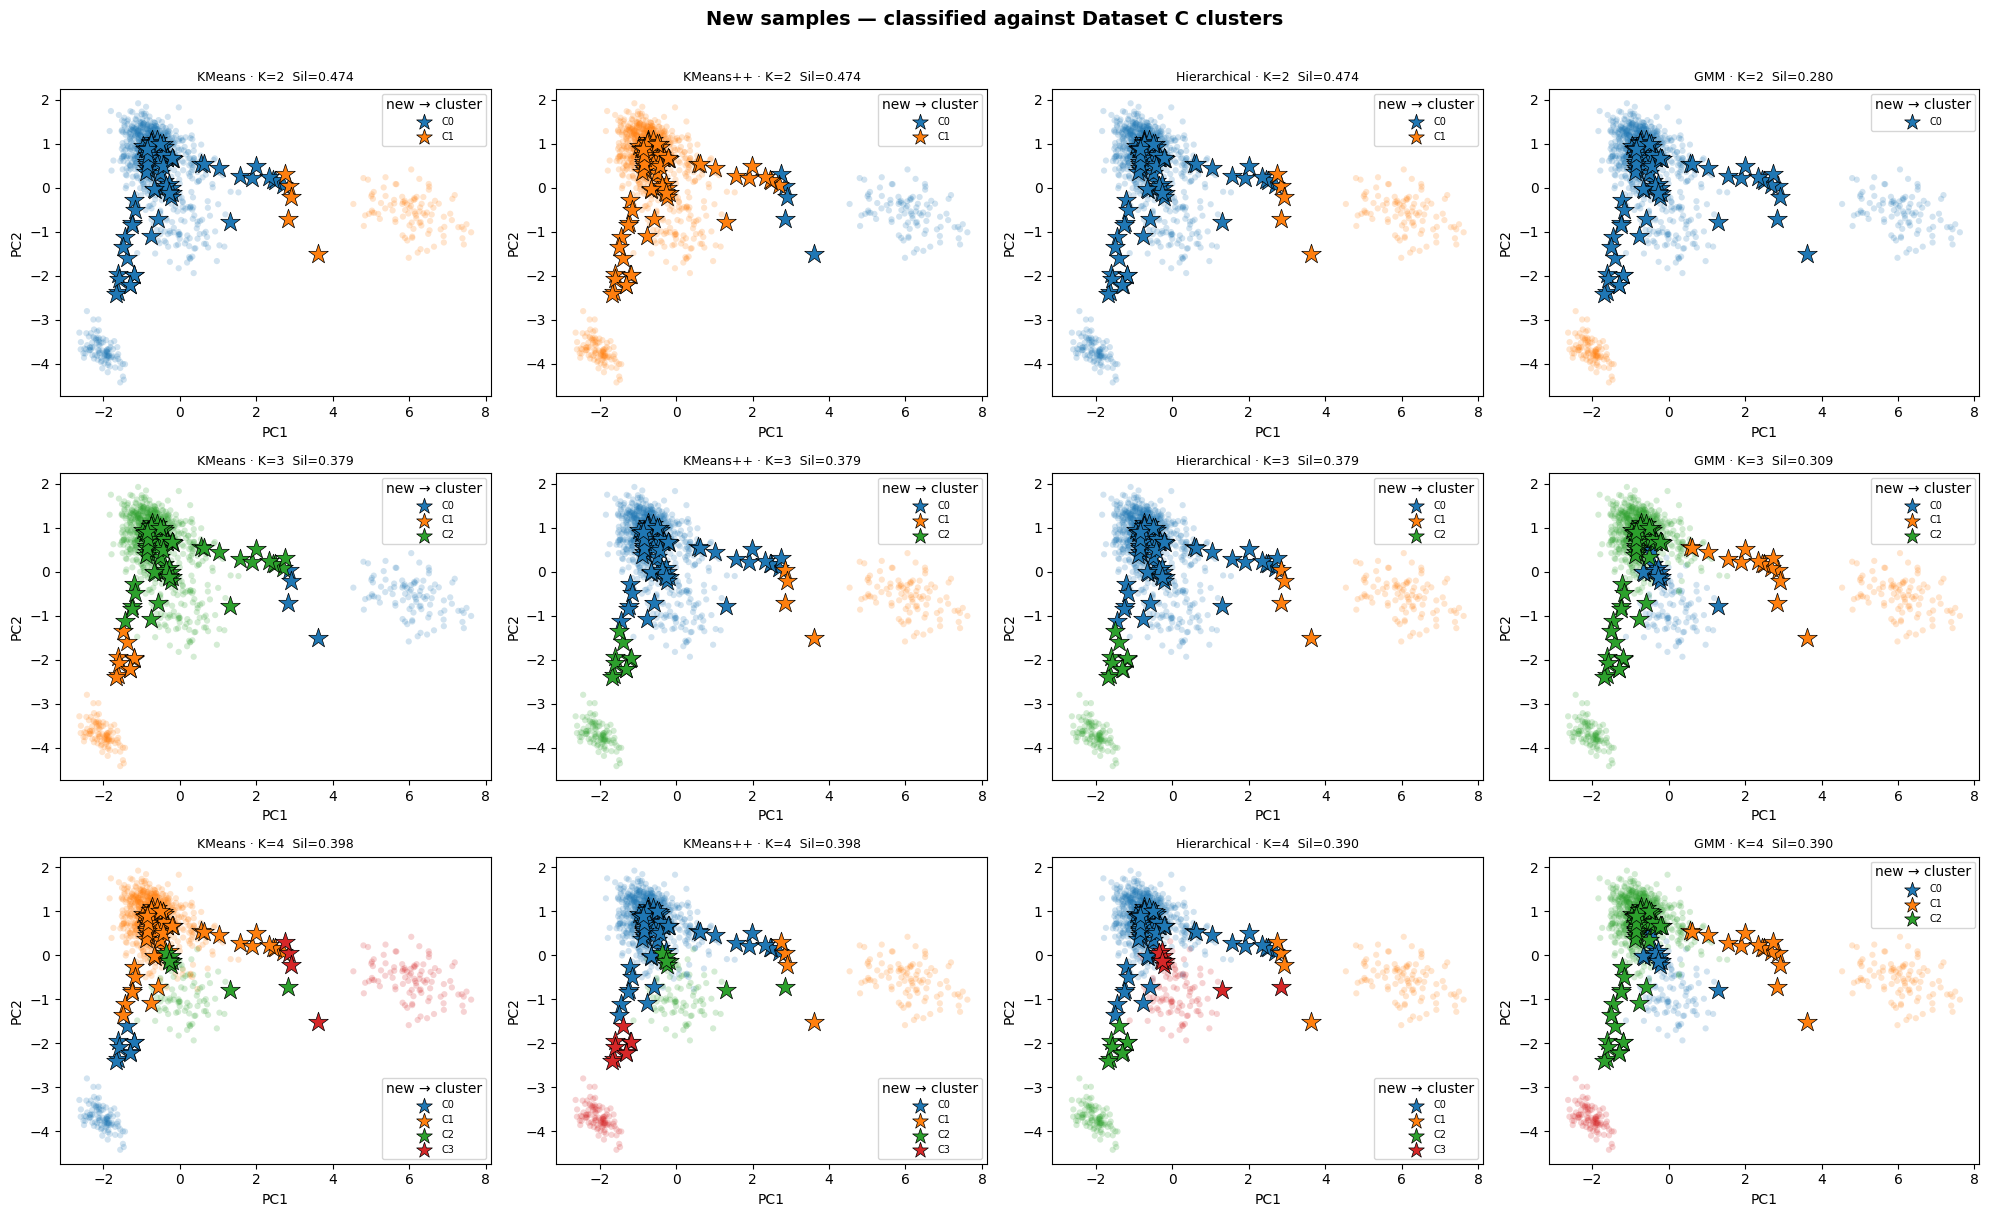

In [44]:
plot.plot_new_samples_pca(
    df_train=df_C,
    df_new=df_new_samples,
    results=results_C,
    predictions_by_k=predictions_by_k,
    algos=ALGOS,
    ks=KS,
    title="New samples — classified against Dataset C clusters",
)